In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

In [5]:
customer_df = pd.read_csv("customer_features.csv")

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_orders,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,favorite_month,favorite_day,country,avg_revenue_per_product,revenue_per_order,products_per_order
0,13085,158,12,77556.46,6463.038333,12,6190.416667,74285,27,0.000363,400,36,January,Friday,United Kingdom,1.044039,6463.038333,6190.416667
1,13078,3,8,4921.53,615.191250,8,370.875000,2967,126,0.042467,402,57,November,Wednesday,Iceland,1.658756,615.191250,370.875000
2,15362,449,5,2019.40,403.880000,5,542.800000,2714,25,0.009211,362,90,December,Tuesday,Finland,0.744068,403.880000,542.800000
3,18102,1,4,4428.69,1107.172500,4,406.000000,1624,138,0.084975,570,190,October,Tuesday,Italy,2.727026,1107.172500,406.000000
4,12682,4,1,334.40,334.400000,1,197.000000,197,17,0.086294,0,0,November,Tuesday,Norway,1.697462,334.400000,197.000000


In [6]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "total_products",
    "unique_products",
    "product_diversity",
    "customer_lifetime_days",
    "avg_purchase_interval",
    "avg_revenue_per_product",
    "revenue_per_order",
    "products_per_order"
]

X = customer_df[features].copy()

X.head()

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order,products_per_order
0,158,12,77556.46,6463.038333,6190.416667,74285,27,0.000363,400,36,1.044039,6463.038333,6190.416667
1,3,8,4921.53,615.191250,370.875000,2967,126,0.042467,402,57,1.658756,615.191250,370.875000
2,449,5,2019.40,403.880000,542.800000,2714,25,0.009211,362,90,0.744068,403.880000,542.800000
3,1,4,4428.69,1107.172500,406.000000,1624,138,0.084975,570,190,2.727026,1107.172500,406.000000
4,4,1,334.40,334.400000,197.000000,197,17,0.086294,0,0,1.697462,334.400000,197.000000


In [7]:
log_features = [
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "total_products",
    "unique_products",
    "customer_lifetime_days",
    "avg_revenue_per_product",
    "revenue_per_order",
    "products_per_order"
]

X[log_features] = np.log1p(X[log_features])

X.head()

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order,products_per_order
0,158,12,11.258774,8.774010,8.730919,11.215678,3.332205,0.000363,5.993961,36,0.714928,8.774010,8.730919
1,3,8,8.501578,6.423557,5.918558,7.995644,4.844187,0.042467,5.998937,57,0.977858,6.423557,5.918558
2,449,5,7.611051,6.003591,6.298582,7.906547,3.258097,0.009211,5.894403,90,0.556220,6.003591,6.298582
3,1,4,8.396085,7.010468,6.008813,7.393263,4.934474,0.084975,6.347389,190,1.315611,7.010468,6.008813
4,4,1,5.815324,5.815324,5.288267,5.288267,2.890372,0.086294,0.000000,0,0.992311,5.815324,5.288267


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5878, 13)


In [9]:
results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)

results_df

,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,56002.323963,0.260400,1.436333,2141.679710
1,3,49240.889252,0.184540,1.627768,1621.031099
2,4,43266.940603,0.203010,1.452566,1500.035394
3,5,39296.490484,0.208843,1.331434,1386.836209
4,6,36348.841504,0.212864,1.212655,1294.471026
5,7,33876.445144,0.189637,1.333625,1228.671897
6,8,31696.860983,0.194441,1.326574,1183.039580
7,9,29925.640919,0.189146,1.348962,1139.658881
8,10,28297.253546,0.174560,1.342782,1108.665596


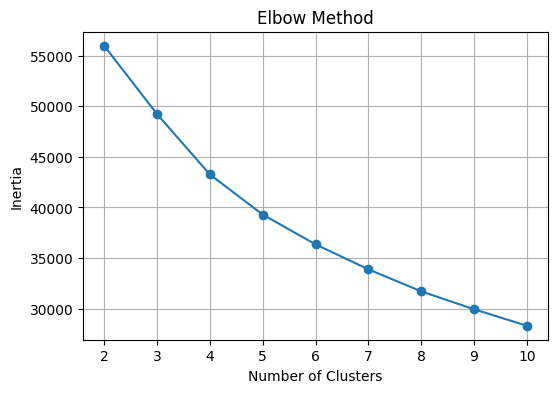

In [10]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Inertia"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

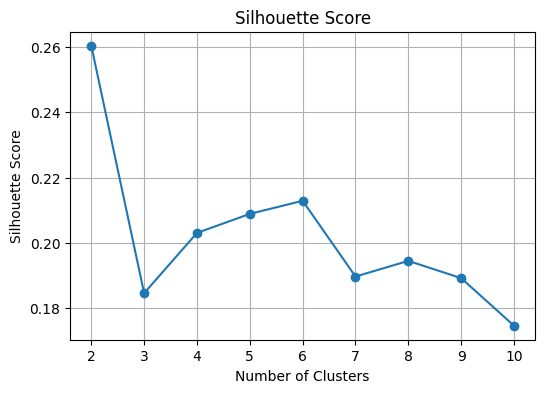

In [11]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Silhouette"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.grid(True)

plt.show()

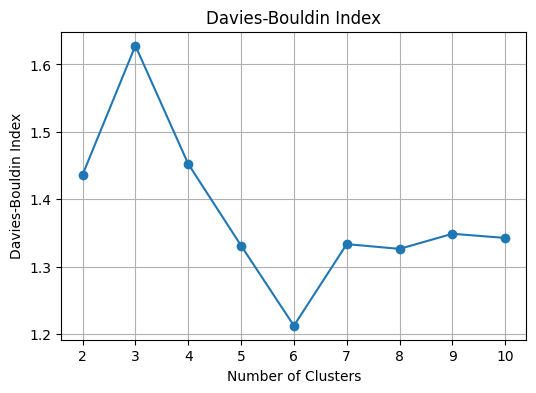

In [12]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Davies_Bouldin"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index")

plt.grid(True)

plt.show()

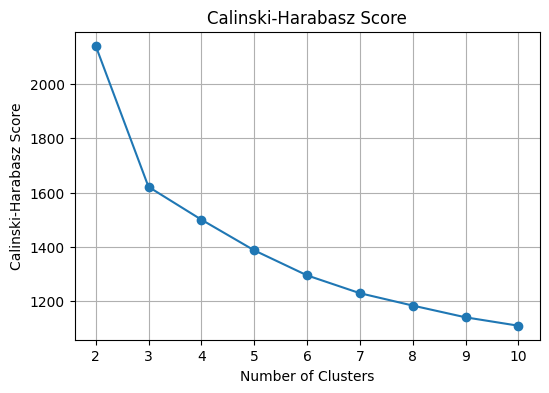

In [13]:
plt.figure(figsize=(6,4))

plt.plot(results_df["K"], results_df["Calinski_Harabasz"], marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")

plt.grid(True)

plt.show()

In [14]:
best_k = 6

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

customer_df["cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,total_orders,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,favorite_month,favorite_day,country,avg_revenue_per_product,revenue_per_order,products_per_order,cluster
0,13085,158,12,77556.46,6463.038333,12,6190.416667,74285,27,0.000363,400,36,January,Friday,United Kingdom,1.044039,6463.038333,6190.416667,4
1,13078,3,8,4921.53,615.191250,8,370.875000,2967,126,0.042467,402,57,November,Wednesday,Iceland,1.658756,615.191250,370.875000,4
2,15362,449,5,2019.40,403.880000,5,542.800000,2714,25,0.009211,362,90,December,Tuesday,Finland,0.744068,403.880000,542.800000,4
3,18102,1,4,4428.69,1107.172500,4,406.000000,1624,138,0.084975,570,190,October,Tuesday,Italy,2.727026,1107.172500,406.000000,4
4,12682,4,1,334.40,334.400000,1,197.000000,197,17,0.086294,0,0,November,Tuesday,Norway,1.697462,334.400000,197.000000,0


cluster
0    1118
1    2083
2     946
3      61
4    1649
5      21
Name: count, dtype: int64


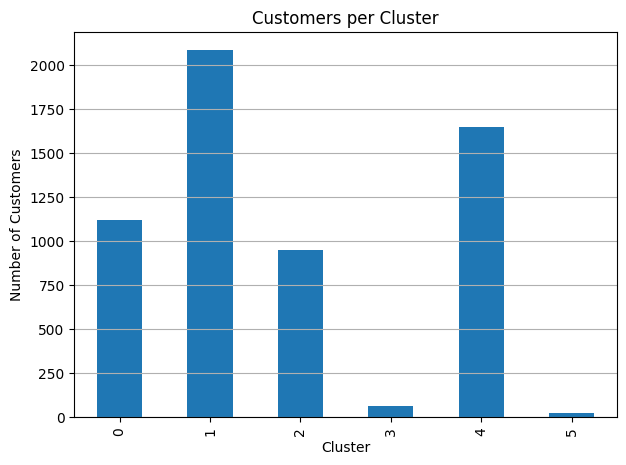

In [15]:
cluster_counts = customer_df["cluster"].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(7,5))

cluster_counts.plot(kind="bar")

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

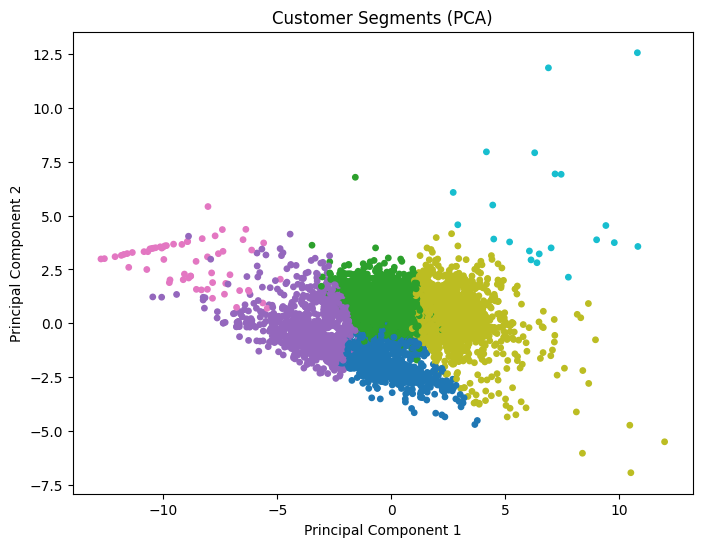

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=customer_df["cluster"],
    cmap="tab10",
    s=15
)

plt.title("Customer Segments (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [18]:
cluster_profile = (
    customer_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,recency,frequency,monetary,avg_order_value,avg_basket_size,total_products,unique_products,product_diversity,customer_lifetime_days,avg_purchase_interval,avg_revenue_per_product,revenue_per_order,products_per_order
cluster,,,,,,,,,,,,,
0,210.35,1.23,497.78,414.34,259.36,308.88,28.68,0.11,4.89,4.18,1.85,414.34,259.36
1,191.14,5.13,1130.65,239.79,132.60,605.65,71.41,0.13,365.05,138.22,2.03,239.79,132.60
2,206.84,1.64,190.92,126.98,58.28,84.41,16.22,0.22,43.24,22.40,2.74,126.98,58.28
3,147.77,1.48,1449.51,750.27,3.50,5.79,2.61,0.75,13.25,2.51,494.72,750.27,3.50
4,206.71,12.06,6749.62,676.21,498.22,4286.90,162.77,0.06,474.44,72.32,1.77,676.21,498.22
5,217.71,161.33,145904.56,971.80,573.74,83701.86,819.38,0.02,709.67,4.67,1.87,971.80,573.74


In [19]:
cluster_summary = (
    customer_df
    .groupby("cluster")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("recency", "mean"),
        Avg_Frequency=("frequency", "mean"),
        Avg_Monetary=("monetary", "mean"),
        Avg_Order_Value=("avg_order_value", "mean"),
        Avg_Basket_Size=("avg_basket_size", "mean")
    )
    .round(2)
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value,Avg_Basket_Size
cluster,,,,,,
0,1118,210.35,1.23,497.78,414.34,259.36
1,2083,191.14,5.13,1130.65,239.79,132.60
2,946,206.84,1.64,190.92,126.98,58.28
3,61,147.77,1.48,1449.51,750.27,3.50
4,1649,206.71,12.06,6749.62,676.21,498.22
5,21,217.71,161.33,145904.56,971.80,573.74


In [20]:
segment_map = {
    0: "One-Time Buyers",
    1: "Regular Customers",
    2: "Low-Value Customers",
    3: "Premium Niche Customers",
    4: "High-Value Loyal Customers",
    5: "VIP Customers"
}

customer_df["segment"] = customer_df["cluster"].map(segment_map)

customer_df[["customer_id", "cluster", "segment"]].head()

,customer_id,cluster,segment
0,13085,4,High-Value Loyal Customers
1,13078,4,High-Value Loyal Customers
2,15362,4,High-Value Loyal Customers
3,18102,4,High-Value Loyal Customers
4,12682,0,One-Time Buyers


In [21]:
segment_distribution = (
    customer_df["segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ["Segment", "Customers"]

segment_distribution

,Segment,Customers
0,Regular Customers,2083
1,High-Value Loyal Customers,1649
2,One-Time Buyers,1118
3,Low-Value Customers,946
4,Premium Niche Customers,61
5,VIP Customers,21


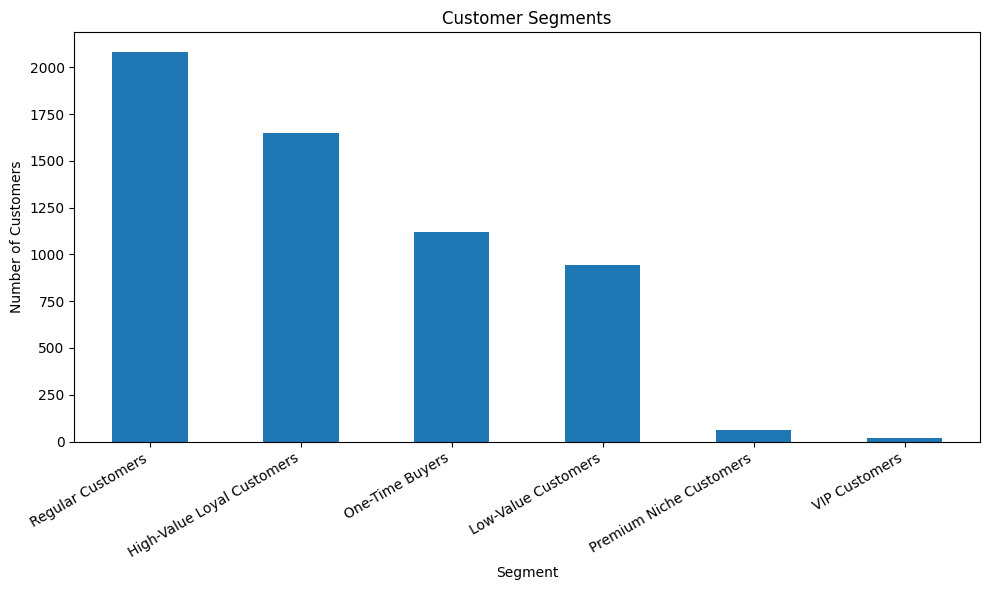

In [22]:
plt.figure(figsize=(10,6))

customer_df["segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

VIP Customers (21 customers)

Highest monetary value (~145k)
Highest purchase frequency
Longest customer lifetime
Strategy: Offer exclusive rewards, concierge support, and early access to products.

High-Value Loyal Customers (1649 customers)

High purchase frequency and spending
Strong long-term engagement
Strategy: Loyalty programs, personalized recommendations, and cross-selling.

Regular Customers (2083 customers)

Moderate purchase frequency and spending
Largest customer segment
Strategy: Increase basket size with promotions and bundles.

One-Time Buyers (1118 customers)

Purchased only once
Limited engagement
Strategy: Welcome emails, first-repeat discounts, and remarketing campaigns.

Low-Value Customers (946 customers)

Low spending and low purchase frequency
Strategy: Targeted promotions and low-cost retention campaigns.

Premium Customers (61 customers)

Very high average order value but infrequent purchases
Strategy: High-touch service and personalized offers to encourage repeat purchases.

In [23]:
customer_df.to_csv("customer_segments.csv", index=False)

print("customer_segments.csv saved successfully!")

customer_segments.csv saved successfully!


In [24]:
cluster_profile.to_csv("cluster_profile.csv")

print("cluster_profile.csv saved successfully!")

cluster_profile.csv saved successfully!
